# Cutout → Structure Tensor → ODF Glyph

**Three-step pipeline:**
1. **Cutout** — download a 3-D ROI from a Neuroglancer link (`ac_data_tools`, optional) or load a local `.tif`
2. **Structure Tensor** — compute principal orientation vectors with `fiberorient.StructureTensor`
3. **ODF Glyph** — build a smoothed ODF (von Mises kernel) and render an anatomically-oriented glyph

> **Axis convention**: `cutout_from_NG` returns `(x, y, z)`. We immediately transpose to `(z, y, x)` for `fiberorient`.


---
## Setup

Install dependencies (run once, then restart the kernel):

```bash
pip install fiberorient pyvista tifffile pillow matplotlib numpy scipy
# Optional — only needed for Option A (cutout from Neuroglancer):
pip install git+https://github.com/AllenInstitute/ac_data_tools.git
```

Also install this package from the repo root:
```bash
pip install -e ..
```


In [30]:
import json
import pathlib

import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from PIL import Image

import pyvista as pv
pv.set_jupyter_backend('static')   # off-screen rendering inside notebooks

from st_odf import (
    StructureTensor,
    make_sphere,
    odf_from_vectors_simple,
    generalized_fractional_anisotropy,
    apply_anatomical_rotation,
)

print('Imports OK')

Imports OK


In [31]:
import os
import sys

# ── Uncomment if running on a network with a custom SSL certificate ───────────
# os.environ['CURL_CA_BUNDLE'] = '/path/to/rootCA.pem'
# os.environ['SSL_CERT_FILE']  = '/path/to/rootCA.pem'

# ── Add repo src to path ─────────────────────────────────────────────────────
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC_PATH  = os.path.join(REPO_ROOT, 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', force=True)
print(f'REPO_ROOT: {REPO_ROOT}')

REPO_ROOT: /home/wanqingyu/cutout-st-odf


---
## Parameters

Edit the cell below to configure the full pipeline.


In [32]:

# ── Dataset configuration ─────────────────────────────────────────────────────
CONFIG_JSON = pathlib.Path(REPO_ROOT) / 'datasets_config.json'
DATASET_ID  = 'H17_PO11_S8'   # ← change to any id in raw_datasets_config.json

# ── Neuroglancer link ─────────────────────────────────────────────────────────
# Paste the shared Neuroglancer link here (click 'Share' in the NG viewer).
# The center position and layer are read from the link automatically.
NG_LINK    = 'https://10.128.142.67/neuroglancer/#!https://json.neurodata.io/v1?NGStateID=ofHAxPR2CWlpwA'
LAYER_NAME = None    # None → auto-detect first layer; or set e.g. 'H17_PO11_S8_20250408'

# ── Cutout size & output ──────────────────────────────────────────────────────
CUTOUT_SIZE = (512, 512, 512)  # (z, y, x) voxels at MIP 0
MIP_LEVEL   = '2'
OUT_DIR     = pathlib.Path('./cutouts')
POST_FIX    = 'pos1'           # appended to the output filename

# ── Structure Tensor ──────────────────────────────────────────────────────────
ST_D_SIGMA = 1    # derivative sigma (controls fine/coarse scale of gradients)
ST_N_SIGMA = 1    # neighbourhood sigma (spatial smoothing)
INTENSITY_THRESHOLD = 6   # voxels below this are excluded from the ODF (0 = no mask)

# ── ODF ───────────────────────────────────────────────────────────────────────
ODF_METHOD    = 'vonmises'   # smoothed histogram kernel: 'vonmises' | 'kde' | 'hist'
ODF_KAPPA     = 20           # concentration parameter (vonmises only; higher = sharper)
SPHERE_POINTS = 6500         # tessellation of the unit sphere
MAX_VECTORS   = 125000           # max number of vectors to estimate ODF from

# ── Glyph & screenshot ────────────────────────────────────────────────────────
GLYPH_SCALE    = 3.0
WINDOW_SIZE    = (900, 900)
# Camera: (position, focal_point, view_up)
# Looks along +Z (A-P / depth axis) — shows the M-L × D-V section face-on.
# view_up=(0,1,0) is standard "Y-up"; flip to (0,-1,0) if the section appears
# upside-down after applying the anatomical rotation.
CAMERA_POS     = [(10, 0, 0), (0, 0, 0), (0, 1, 0)]
SCREENSHOT_PNG = OUT_DIR / f'odf_glyph_{DATASET_ID}.png'


---
## Load Anatomical Rotation from Config


In [33]:
with open(CONFIG_JSON) as f:
    cfg = json.load(f)

datasets = {d['id']: d for d in cfg.get('datasets', [])}
entry = datasets.get(DATASET_ID)
if entry is None:
    raise ValueError(f"'{DATASET_ID}' not found in {CONFIG_JSON}. Available: {list(datasets)}")

ANATOMICAL_ROTATION = np.array(
    entry.get('anatomical_rotation', [[1, 0, 0], [0, 1, 0], [0, 0, 1]])
)
# dec_rgb_order: [r_axis, g_axis, b_axis] — indices into the anatomically-rotated vector
# Convention: horizontal=R, vertical=G, depth=B
DEC_RGB_ORDER = entry.get('dec_rgb_order', [0, 1, 2])

print(f'Dataset         : {DATASET_ID}')
print(f'Anatomical rot  :\n{ANATOMICAL_ROTATION}')
print(f'DEC RGB order   : anat-{DEC_RGB_ORDER[0]}→R  anat-{DEC_RGB_ORDER[1]}→G  anat-{DEC_RGB_ORDER[2]}→B')


Dataset         : H17_PO11_S8
Anatomical rot  :
[[-1  0  0]
 [ 0 -1  0]
 [ 0  0  1]]
DEC RGB order   : anat-2→R  anat-1→G  anat-0→B


---
## Step 1: Cutout

**Option A** — download from a Neuroglancer zarr store via `cutout_from_NG` (requires `ac_data_tools`).  
**Option B** — load a local `.tif` file.

> **Axis note**: `cutout_from_NG` returns `(x, y, z)`. We transpose immediately to `(z, y, x)` for `fiberorient`.


In [34]:
# ── Option A: cutout from Neuroglancer ───────────────────────────────────────
from ac_data_tools.cutout import cutout_from_NG

OUT_DIR.mkdir(parents=True, exist_ok=True)

cutout, metadata = cutout_from_NG(
    ng_link    = NG_LINK,
    layer_name = LAYER_NAME,
    size       = CUTOUT_SIZE,
    out_path   = str(OUT_DIR),
    post_fix   = POST_FIX,
    mip        = MIP_LEVEL,
    save_tif   = True,
)
# cutout_from_NG returns (x, y, z); transpose to (z, y, x) for fiberorient
img = cutout
TIF_PATH = pathlib.Path(metadata['tif_path'])
print(f'Image shape (z, y, x): {img.shape}')


INFO: Starting cross-source cutout with merge strategy: first_valid
/home/wanqingyu/cutout-st-odf/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'json.neurodata.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
INFO: Found 7 data source(s) for layer 'H17_PO11_S8_20250408':
INFO:   1: H17_PO11_S8_20250408_src0 -> https://10.128.142.67/fs//allen/aind/stage/svc_axonal/hpc/contrast/EXASPIM/H17_PO11_S8_20250408/sharded/exaSPIM_0_0.zarr/
INFO:   2: H17_PO11_S8_20250408_src1 -> https://10.128.142.67/fs//allen/aind/stage/svc_axonal/hpc/contrast/EXASPIM/H17_PO11_S8_20250408/sharded/exaSPIM_1_0.zarr/
INFO:   3: H17_PO11_S8_20250408_src2 -> https://10.128.142.67/fs//allen/aind/stage/svc_axonal/hpc/contrast/EXASPIM/H17_PO11_S8_20250408/sharded/exaSPIM_2_0.zarr/
INFO:   4: H17_PO11_S8_20250408_src3 -> https

Image shape (z, y, x): (128, 128, 128)


In [35]:
# ── Option B: local tif ───────────────────────────────────────────────────────
# Uncomment and set the path to your tif file.
# tifffile reads tifs saved by cutout_from_NG as (z, y, x) automatically.

# TIF_PATH = pathlib.Path('/path/to/your/cutout.tif')
# img = tiff.imread(str(TIF_PATH))
# print(f'Image shape (z, y, x): {img.shape}')


In [36]:
# print(f'Image shape (z, y, x): {img.shape}  dtype: {img.dtype}')
# print(f'Intensity range: [{img.min()}, {img.max()}]')

# mz, my, mx = [s // 2 for s in img.shape]

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, proj, label in zip(
#     axes,
#     [img[mz, :, :], img[:, my, :], img[:, :, mx]],
#     [f'Mid-Z={mz} (YX plane)', f'Mid-Y={my} (XZ plane)', f'Mid-X={mx} (ZY plane)'],
# ):
#     ax.imshow(proj, cmap='gray')
#     ax.set_title(label)
#     ax.axis('off')

# plt.suptitle(f'Cutout middle planes — {DATASET_ID}', fontsize=13)
# plt.tight_layout()
# plt.show()


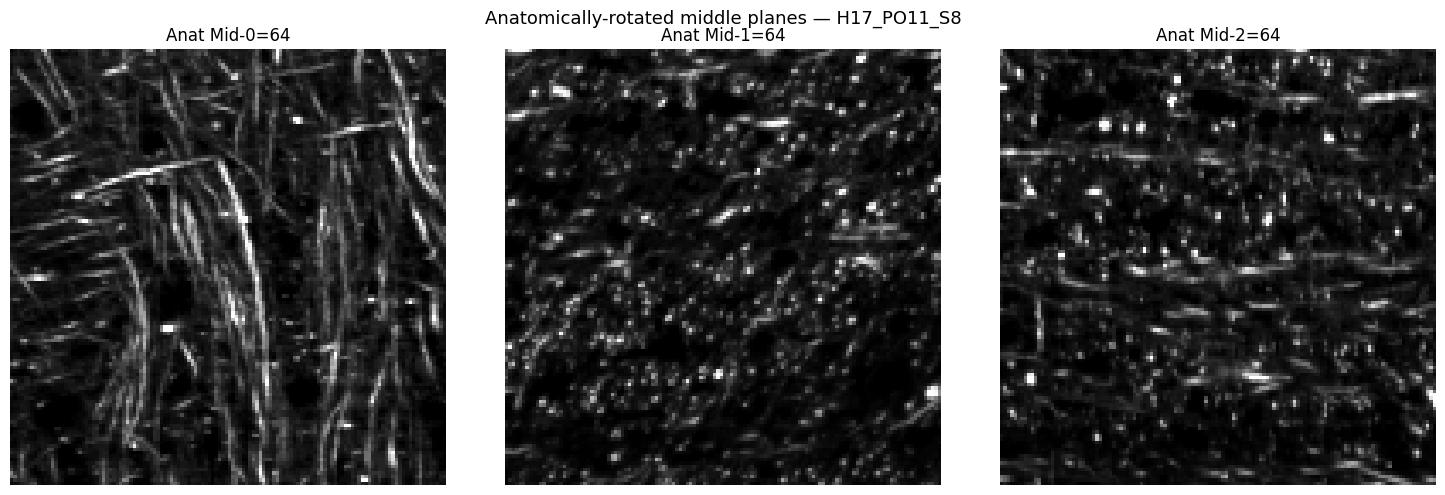

In [37]:
from scipy.ndimage import affine_transform as _aff

def _rotate_vol(vol, R):
    c = (np.array(vol.shape) - 1) / 2.0
    offset = c - R.T @ c
    return _aff(vol.astype(np.float32), R.T, offset=offset, order=1, mode='constant', cval=0)

img_anat = _rotate_vol(img, ANATOMICAL_ROTATION)
mz, my, mx = [s // 2 for s in img_anat.shape]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, proj, label in zip(
    axes,
    [img_anat[mz], img_anat[:, my, :], img_anat[:, :, mx]],
    [f'Anat Mid-0={mz}', f'Anat Mid-1={my}', f'Anat Mid-2={mx}'],
):
    ax.imshow(proj, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.suptitle(f'Anatomically-rotated middle planes — {DATASET_ID}', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 2: Structure Tensor

`fiberorient.StructureTensor` computes the gradient structure tensor and returns
the principal eigenvector (local fibre orientation) as a `(Z, Y, X, 3)` array.


In [38]:
st = StructureTensor(d_sigma=ST_D_SIGMA, n_sigma=ST_N_SIGMA)
st.fit(img)
vectors = st.vectors   # shape: (Z, Y, X, 3)
print(f'Vectors shape: {vectors.shape}')


INFO: Computing gradient
INFO: Forming ST elements
INFO: Calculating eigenvectors/values
INFO: Done!


Vectors shape: (128, 128, 128, 3)


In [39]:
# Direction-Encoded Colour (DEC) image
# Rotate vectors to anatomical space, then permute components to R/G/B per DEC_RGB_ORDER
vectors_anat = vectors @ ANATOMICAL_ROTATION.T   # (Z, Y, X, 3)

v = np.abs(vectors_anat)
v = v / v.max()
scalar = (img.astype(np.float32) - img.min()) / (img.max() - img.min() + 1e-8) * 255.0
dec_img = (scalar[..., None] * v[..., DEC_RGB_ORDER]).astype(np.uint8)   # (Z, Y, X, 3)


In [40]:

# axis_labels = [f'anat-{i}' for i in DEC_RGB_ORDER]
# mz, my, mx = [s // 2 for s in img.shape]
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, proj, label in zip(
#     axes,
#     [dec_img[mz, :, :], dec_img[:, my, :], dec_img[:, :, mx]],
#     [f'DEC Mid-Z={mz}', f'DEC Mid-Y={my}', f'DEC Mid-X={mx}'],
# ):
#     ax.imshow(proj)
#     ax.set_title(label)
#     ax.axis('off')
# plt.suptitle(f'DEC  R={axis_labels[0]}  G={axis_labels[1]}  B={axis_labels[2]}  (horizontal=R, vertical=G, depth=B)', fontsize=12)
# plt.tight_layout()
# plt.show()


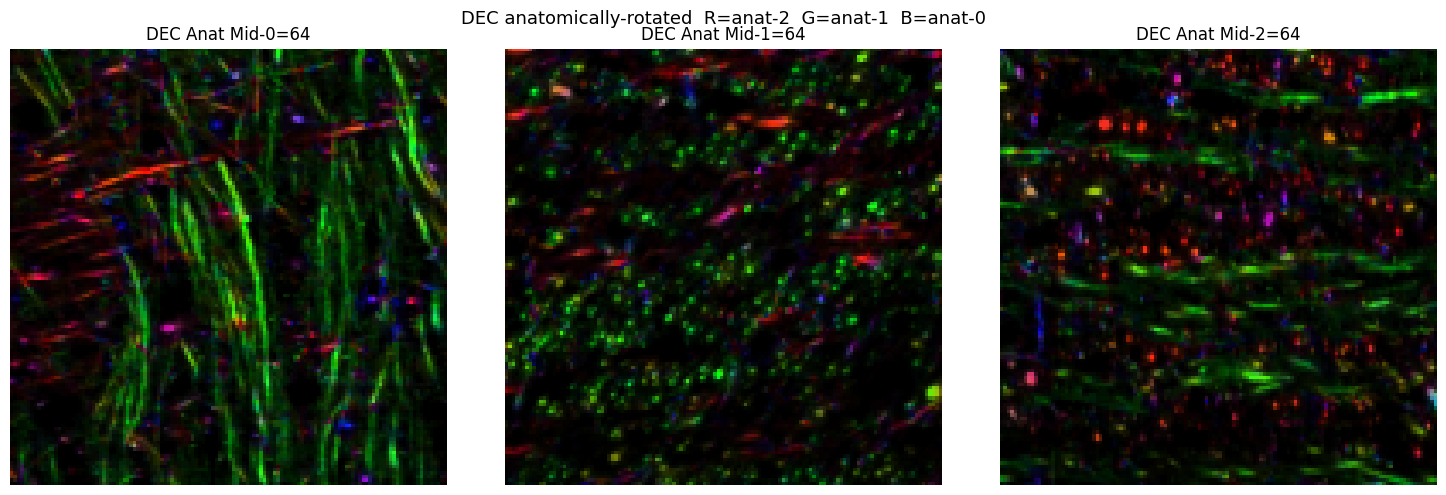

In [41]:
dec_anat = np.stack([_rotate_vol(dec_img[..., c], ANATOMICAL_ROTATION) for c in range(3)], axis=-1).clip(0, 255).astype(np.uint8)
mz, my, mx = [s // 2 for s in dec_anat.shape[:3]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, proj, label in zip(
    axes,
    [dec_anat[mz], dec_anat[:, my, :], dec_anat[:, :, mx]],
    [f'DEC Anat Mid-0={mz}', f'DEC Anat Mid-1={my}', f'DEC Anat Mid-2={mx}'],
):
    ax.imshow(proj)
    ax.set_title(label)
    ax.axis('off')

axis_labels = [f'anat-{i}' for i in DEC_RGB_ORDER]
plt.suptitle(f'DEC anatomically-rotated  R={axis_labels[0]}  G={axis_labels[1]}  B={axis_labels[2]}', fontsize=13)
plt.tight_layout()
plt.show()


---
## Step 3: ODF Glyph (Smoothed Histogram — von Mises)

Each foreground voxel contributes its principal orientation vector to a directional
histogram on the unit sphere. The von Mises kernel gives a smooth, continuous ODF.

The glyph is rendered off-screen with **PyVista** using the anatomical rotation from
the dataset config, then saved as a PNG.

> **Antipodal symmetry**: eigenvectors have arbitrary sign, so we include both **v** and **−v**
> before computing the ODF to ensure both hemispheres are populated.


In [ ]:
sphere = make_sphere(SPHERE_POINTS)

# Foreground mask
mask = (img > INTENSITY_THRESHOLD) if INTENSITY_THRESHOLD > 0 else np.ones(img.shape, dtype=bool)
vectors_fg = vectors[mask]
print(f'Foreground voxels : {vectors_fg.shape[0]:,}')

# Subsample for speed — statistics converge well before N=500K
if len(vectors_fg) > MAX_VECTORS:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(vectors_fg), size=MAX_VECTORS, replace=False)
    vectors_odf = vectors_fg[idx]
    print(f'Subsampled to     : {MAX_VECTORS:,} vectors for ODF')
else:
    vectors_odf = vectors_fg

# Enforce antipodal symmetry: include both v and -v
vectors_odf = np.concatenate([vectors_odf, -vectors_odf], axis=0)

odf_on_sphere = odf_from_vectors_simple(
    vectors_odf, sphere.vertices,
    method=ODF_METHOD, kappa=ODF_KAPPA, normalize=True,
)

gfa = generalized_fractional_anisotropy(odf_on_sphere)
print(f'GFA : {gfa:.4f}')


Foreground voxels : 1,724,526
Subsampled to     : 125,000 vectors for ODF


Screenshot saved: cutouts/odf_glyph_H17_PO11_S8.png


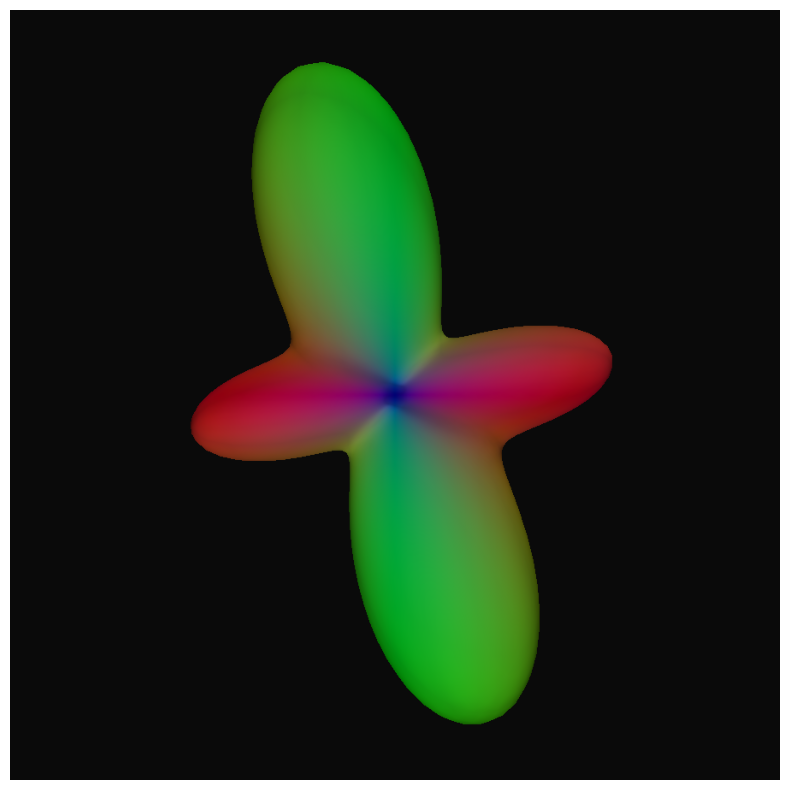

In [ ]:

# ── 1. Build glyph mesh in anatomical orientation ────────────────────────────────────────────
rot_verts = apply_anatomical_rotation(sphere.vertices, ANATOMICAL_ROTATION)

values_clipped = np.clip(odf_on_sphere, 0, None)
vmax          = values_clipped.max()
values_norm   = values_clipped / vmax if vmax > 0 else values_clipped

verts = rot_verts * (values_norm * GLYPH_SCALE)[:, None]

# Direction-encoded RGB colours — use absolute values of the unit-sphere
# vertices in anatomical space, then reorder channels per DEC_RGB_ORDER so
# the glyph colours match the DEC images produced in Step 2.
# rot_verts are on the unit sphere (|v|=1), so |x|,|y|,|z| ∈ [0,1] directly.
rgb = np.abs(rot_verts)[:, DEC_RGB_ORDER]   # shape (N, 3), values in [0, 1]

# Build PyVista PolyData
if sphere.faces.ndim > 1:
    faces_padded = np.column_stack(
        [np.full(sphere.faces.shape[0], 3), sphere.faces]
    ).ravel()
else:
    faces_padded = sphere.faces

odf_mesh = pv.PolyData(verts, faces=faces_padded)
odf_mesh['colors'] = rgb

# ── 2. Render ────────────────────────────────────────────────────────────────────────────
plotter = pv.Plotter(window_size=WINDOW_SIZE, off_screen=True)
plotter.set_background('#0a0a0a')
plotter.add_mesh(
    odf_mesh, scalars='colors', rgb=True,
    opacity=0.85, smooth_shading=True,
)

plotter.camera_position = CAMERA_POS
plotter.camera.zoom(0.8)

SCREENSHOT_PNG.parent.mkdir(parents=True, exist_ok=True)
plotter.screenshot(str(SCREENSHOT_PNG))
print(f'Screenshot saved: {SCREENSHOT_PNG}')

# ── 3. Display inline ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.imshow(np.array(Image.open(SCREENSHOT_PNG)))
plt.axis('off')
# plt.title(f'ODF Glyph — {DATASET_ID}', fontsize=13)
plt.tight_layout()
plt.show()


---
## Tips

| Goal | What to change |
|------|----------------|
| Different dataset | `DATASET_ID` + add entry to `datasets_config.json` |
| Different region | `NG_LINK` (paste a new Neuroglancer share link) |
| No Neuroglancer access | Use Option B in Step 1 to load a local `.tif` |
| Sharper / smoother ODF | `ODF_KAPPA` (higher = sharper for `vonmises`) |
| Different kernel | `ODF_METHOD = 'kde'` or `'hist'` |
| Change view angle | `CAMERA_POS` — e.g. `[(10,0,0),(0,0,0),(0,-1,0)]` for YZ view |
| Larger screenshot | `WINDOW_SIZE = (1200, 1200)` |
| Faster ODF | Reduce `MAX_VECTORS` or `SPHERE_POINTS` |
